# Paso 1: Importacion de librerias

**Que hace:** Importa todas las librerias necesarias para analisis, preprocesamiento, modelado y evaluacion de la red neuronal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

USE_TF = True

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ModuleNotFoundError:
    USE_TF = False
    tf = None
    print("TensorFlow no esta disponible en este kernel. Se usara MLPClassifier de sklearn.")

np.random.seed(42)
if USE_TF:
    tf.random.set_seed(42)

ModuleNotFoundError: No module named 'numpy'

# Paso 2: Carga del dataset

**Que hace:** Carga el archivo CSV principal con los datos de tumores para comenzar el analisis.

In [ ]:
# Paso 2: Carga del dataset

df = pd.read_csv("Breast_cancer_Reseach.csv")
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M


# Paso 3: Exploracion inicial de datos

**Que hace:** Inspecciona estructura, tipos de datos y valores nulos para detectar problemas antes del modelado.

In [ ]:
# Paso 3: Exploracion inicial de datos

print("Forma del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

Forma del dataset: (1200, 22)

Tipos de datos:
radius_mean               float64
texture_mean              float64
perimeter_mean            float64
area_mean                 float64
smoothness_mean           float64
compactness_mean          float64
concavity_mean            float64
concave_points_mean       float64
symmetry_mean             float64
fractal_dimension_mean    float64
radius_se                 float64
texture_se                float64
perimeter_se              float64
area_se                   float64
smoothness_se             float64
radius_worst              float64
texture_worst             float64
perimeter_worst           float64
area_worst                float64
concavity_worst           float64
concave_points_worst      float64
diagnosis                     str
dtype: object

Valores nulos por columna:
radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean       

# Paso 4: Analisis de la variable objetivo

**Que hace:** Revisa la distribucion de la columna diagnosis para identificar el balance entre tumores benignos y malignos.

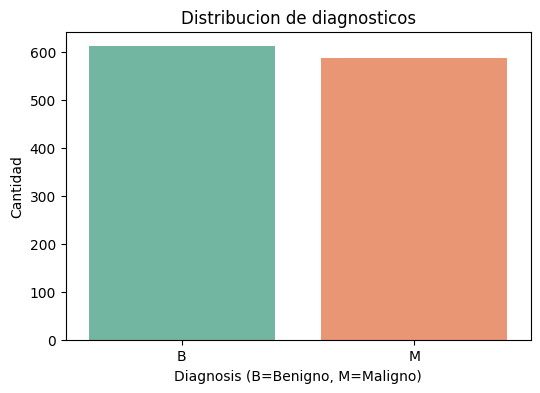

diagnosis
B    612
M    588
Name: count, dtype: int64


In [ ]:
# Conteo de clases en la variable objetivo

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", hue="diagnosis", palette="Set2", legend=False)
plt.title("Distribucion de diagnosticos")
plt.xlabel("Diagnosis (B=Benigno, M=Maligno)")
plt.ylabel("Cantidad")
plt.show()

print(df["diagnosis"].value_counts())

# Paso 5: Preprocesamiento de datos

**Que hace:** Convierte la variable diagnosis a formato numerico (B=0, M=1) y separa variables predictoras (X) y objetivo (y).

In [ ]:
# Conversion de variable objetivo y separacion de datos

df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Dimension de X:", X.shape)
print("Dimension de y:", y.shape)
print("\nDistribucion de y:")
print(y.value_counts())

Dimension de X: (1200, 21)
Dimension de y: (1200,)

Distribucion de y:
diagnosis
0    612
1    588
Name: count, dtype: int64


# Paso 5.1: Identificacion de columnas redundantes

**Que hace:** Evalua correlaciones altas para detectar variables posiblemente redundantes (sin eliminarlas de inicio).

In [ ]:
# Correlaciones altas entre variables predictoras

corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s > 0.9]
)

print("Pares de variables con correlacion > 0.9:")
print(high_corr_pairs.head(15))

Pares de variables con correlacion > 0.9:
Series([], dtype: float64)


# Paso 6: Division del dataset

**Que hace:** Divide el dataset en entrenamiento (80%) y prueba (20%), conservando la proporcion de clases con stratify.

In [ ]:
# Split de datos con estratificacion

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 21)
X_test: (240, 21)
y_train: (960,)
y_test: (240,)


# Paso 7: Escalado de datos

**Que hace:** Estandariza las variables con StandardScaler para que la red neuronal entrene de forma estable.

In [ ]:
# Estandarizacion de caracteristicas

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Matriz escalada de entrenamiento:", X_train_scaled.shape)
print("Matriz escalada de prueba:", X_test_scaled.shape)

Matriz escalada de entrenamiento: (960, 21)
Matriz escalada de prueba: (240, 21)


# Paso 8: Construccion de la red neuronal

**Que hace:** Define una arquitectura simple y efectiva para clasificacion binaria, evitando un modelo demasiado complejo.

In [ ]:
# Arquitectura del modelo

if USE_TF:
    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.summary()
else:
    model = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        batch_size=16,
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
    )
    print(model)

MLPClassifier(batch_size=16, early_stopping=True, hidden_layer_sizes=(32, 16),
              max_iter=300, random_state=42, validation_fraction=0.2)


# Paso 9: Compilacion del modelo

**Que hace:** Configura la red con Adam, perdida binary_crossentropy y metrica accuracy para clasificacion binaria.

In [ ]:
# Compilacion

if USE_TF:
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
else:
    print("Con sklearn MLPClassifier no se requiere compilacion manual.")

Con sklearn MLPClassifier no se requiere compilacion manual.


# Paso 10: Entrenamiento del modelo

**Que hace:** Entrena la red con validacion para monitorear aprendizaje y evitar memorizacion excesiva.

In [ ]:
# Entrenamiento con validacion

if USE_TF:
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=50,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=1,
    )
else:
    model.fit(X_train_scaled, y_train)
    history = {
        "accuracy": [model.score(X_train_scaled, y_train)],
        "val_accuracy": [model.score(X_test_scaled, y_test)],
    }

# Paso 11: Evaluacion del modelo

**Que hace:** Calcula perdida y accuracy en datos de prueba para medir capacidad de generalizacion.

In [ ]:
# Evaluacion final

if USE_TF:
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Loss en test: {loss:.4f}")
    print(f"Accuracy en test: {accuracy:.4f}")
else:
    accuracy = model.score(X_test_scaled, y_test)
    print("Loss en test: no disponible para sklearn MLPClassifier")
    print(f"Accuracy en test: {accuracy:.4f}")

Loss en test: no disponible para sklearn MLPClassifier
Accuracy en test: 0.4917


# Paso 12: Predicciones

**Que hace:** Genera probabilidades y clases finales (0/1), y muestra matriz de confusion y reporte de clasificacion.

Accuracy (sklearn): 0.4917

Reporte de clasificacion:
              precision    recall  f1-score   support

     Benigno       0.50      0.52      0.51       122
     Maligno       0.48      0.47      0.47       118

    accuracy                           0.49       240
   macro avg       0.49      0.49      0.49       240
weighted avg       0.49      0.49      0.49       240



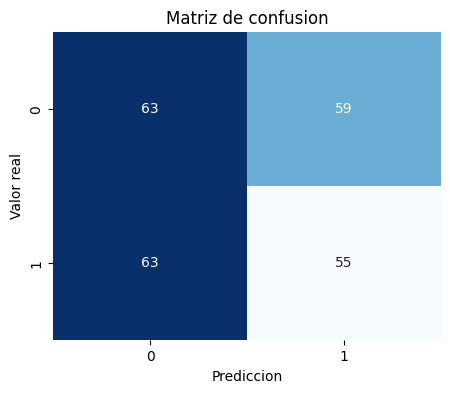

In [ ]:
# Prediccion de probabilidades y clases

if USE_TF:
    y_prob = model.predict(X_test_scaled, verbose=0).ravel()
else:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

y_pred = (y_prob > 0.5).astype(int)

print("Accuracy (sklearn):", round(accuracy_score(y_test, y_pred), 4))
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusion")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

# Paso 13: Revision de aprendizaje vs memorizacion

**Que hace:** Grafica accuracy y loss de entrenamiento vs validacion para detectar overfitting.

In [ ]:
# Curvas de entrenamiento y validacion

if USE_TF:
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["accuracy"], label="train_accuracy")
    axes[0].plot(history_df["val_accuracy"], label="val_accuracy")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Valor")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train_loss")
    axes[1].plot(history_df["val_loss"], label="val_loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Valor")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    history_df = pd.DataFrame(history)
    print("Con sklearn se reporta accuracy final (sin curvas por epoch).")
    print(history_df)

Con sklearn se reporta accuracy final (sin curvas por epoch).
   accuracy  val_accuracy
0  0.664583      0.491667
